# Snakey Plot

In [1]:
import pandas as pd
import plotly.graph_objects as go

In [2]:
file_path = "/scratch/indikar_root/indikar1/shared_data/for_joshua/sankey_inputs.csv"
df = pd.read_csv(file_path)
df

,gene_name,C1,C2,C3,CLP,HSC,LMPP,intial,progenitors
0,A1BG,NE,NE,NE,NE,NE,NE,NE,NE
1,A1BG-AS1,NE,NE,NE,NE,NE,NE,NE,NE
2,A2M,single,single,single,NE,NE,NE,single,NE
3,A2M-AS1,NE,NE,NE,NE,NE,NE,NE,NE
4,A2ML1,NE,NE,NE,NE,single,single,NE,single
...,...,...,...,...,...,...,...,...,...
29077,ZYG11B,single,multi,multi,single,single,single,multi,single
29078,ZYX,single,single,single,NE,multi,single,multi,multi
29079,ZZEF1,single,single,single,single,single,single,multi,multi
29080,ZZZ3,single,single,single,single,multi,single,multi,multi


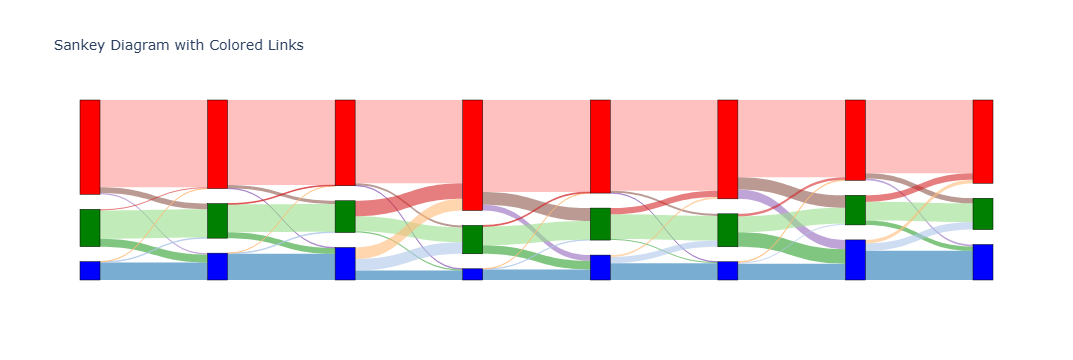

In [5]:
source, target, value, link_colors = [], [], [], []

# Define all possible transitions
transitions = ['multi', 'single', 'NE']
transition_index = {(from_t, to_t): i * 3 + j for i, from_t in enumerate(transitions) for j, to_t in enumerate(transitions)}
transition_colors = {
    ('multi', 'multi'): 'rgba(31, 119, 180, 0.6)',
    ('multi', 'single'): 'rgba(174, 199, 232, 0.6)',
    ('multi', 'NE'): 'rgba(255, 187, 120, 0.6)',
    ('single', 'multi'): 'rgba(44, 160, 44, 0.6)',
    ('single', 'single'): 'rgba(152, 223, 138, 0.6)',
    ('single', 'NE'): 'rgba(214, 39, 40, 0.6)',
    ('NE', 'multi'): 'rgba(148, 103, 189, 0.6)',
    ('NE', 'single'): 'rgba(140, 86, 75, 0.6)',
    ('NE', 'NE'): 'rgba(255, 152, 150, 0.6)'
}

for col in range(1, df.shape[1] - 1):
    s = [(col - 1) * 3 + i for i in range(3)] * 3
    t = sum([[col * 3 + i] * 3 for i in range(3)], [])

    source.extend(s)
    target.extend(t)

    # Count transitions
    counts = {k: 0 for k in transition_index}
    for from_val, to_val in zip(df.iloc[:, col], df.iloc[:, col + 1]):
        if from_val in transitions and to_val in transitions:
            counts[(from_val, to_val)] += 1

    # Fill values in the correct order
    for to_t in transitions:
        for from_t in transitions:
            value.append(counts[(from_t, to_t)])
            link_colors.append(transition_colors[(from_t, to_t)])

# Define node labels and colors
num_steps = df.shape[1] - 1
# node_labels = sum([[f"{label}_{step}" for label in transitions] for step in range(num_steps)], [])
node_labels = sum([[f" " for label in transitions] for step in range(num_steps)], [])
node_colors = (['blue', 'green', 'red'] * num_steps)

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value,
        color=link_colors
    )
)])

fig.update_layout(title_text="Sankey Diagram with Colored Links", font_size=10)
fig.show()
